In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import AdaBoostRegressor
import matplotlib.pyplot as plt


In [8]:
df = pd.read_csv("../Dataset/cardekho_imputated.csv")

df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [9]:
cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

cat_cols, num_cols


(Index(['car_name', 'brand', 'model', 'seller_type', 'fuel_type',
        'transmission_type'],
       dtype='object'),
 Index(['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine',
        'max_power', 'seats', 'selling_price'],
       dtype='object'))

In [10]:
df.drop(columns=['Unnamed: 0'], inplace=True)


In [11]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()


,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,65,18,7,9,120000,1,4,1,19.70,796,46.30,5,120000
1,34,8,54,5,20000,1,4,1,18.90,1197,82.00,5,550000
2,40,8,118,11,60000,1,4,1,17.00,1197,80.00,5,215000
3,65,18,7,9,37000,1,4,1,20.92,998,67.10,5,226000
4,20,6,38,6,30000,0,1,1,22.77,1498,98.59,5,570000


In [12]:
X = df.drop(columns=['selling_price'])
y = df['selling_price']

X.shape, y.shape


((15411, 12), (15411,))

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [14]:
ada = AdaBoostRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

ada.fit(X_train, y_train)


AdaBoostRegressor(learning_rate=0.05, n_estimators=300, random_state=42)

In [15]:
y_pred = ada.predict(X_test)
y_pred[:10]


array([ 561492.54274282,  561492.54274282,  639775.93240093,
        723304.36590437,  561492.54274282,  723772.17654695,
        561492.54274282,  561492.54274282,  671089.89657916,
       1842332.86713287])

In [16]:
mae = mean_absolute_error(y_test, y_pred)
mae


270873.6926598528

In [17]:
mse = mean_squared_error(y_test, y_pred)
mse


180145936797.22897

In [18]:
rmse = np.sqrt(mse)
rmse


424436.0220306813

In [19]:
r2 = r2_score(y_test, y_pred)
r2


0.7606930201093285

In [20]:
n = X_test.shape[0]
p = X_test.shape[1]

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
adj_r2


0.7597576182335344

In [21]:
feature_importance = pd.Series(
    ada.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)


max_power      0.593494
km_driven      0.185553
vehicle_age    0.073407
engine         0.061531
mileage        0.054149
model          0.011130
brand          0.010145
car_name       0.005930
seller_type    0.002358
seats          0.002145
dtype: float64

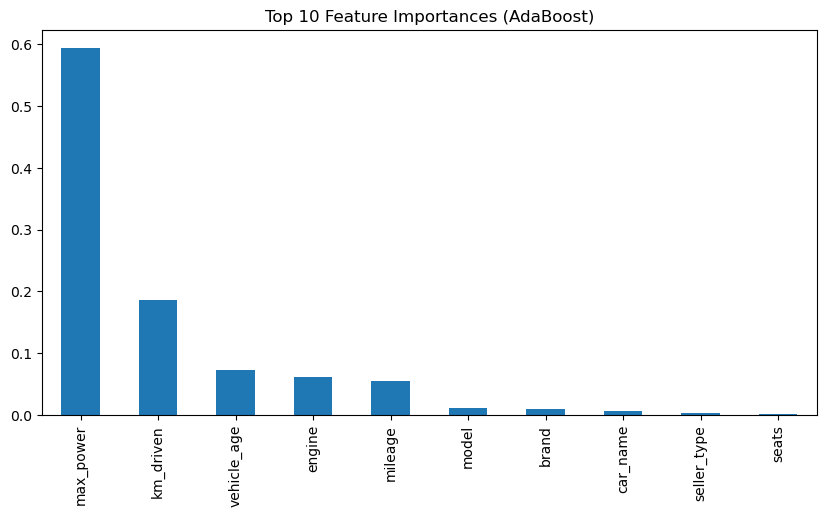

In [22]:
feature_importance.head(10).plot(
    kind='bar',
    figsize=(10,5),
    title='Top 10 Feature Importances (AdaBoost)'
)
plt.show()


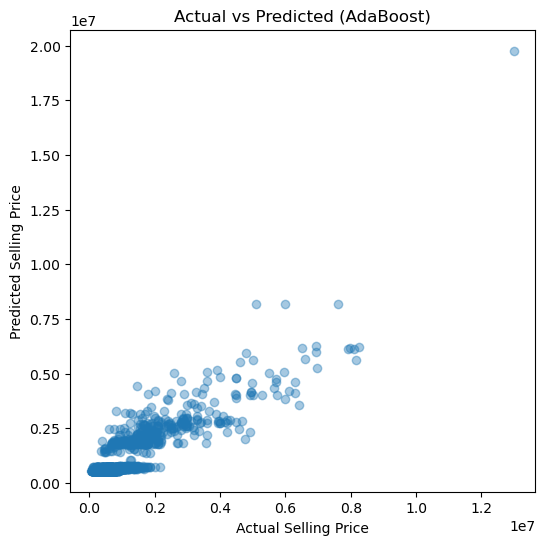

In [23]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted (AdaBoost)")
plt.show()
